In [ ]:
pip install yfinance


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns


ticker = "^HSI"
start_date = "2018-01-01"
end_date= None

data= yf.download(ticker, start_date, end_date)

data.head()

/tmp/ipython-input-1113387266.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^HSI,^HSI,^HSI,^HSI,^HSI
Date,,,,,
2018-01-02,30515.310547,30515.310547,30028.289062,30028.289062,2442300000
2018-01-03,30560.949219,30724.320312,30456.759766,30658.730469,2309500000
2018-01-04,30736.480469,30796.929688,30560.429688,30691.710938,2995600000
2018-01-05,30814.640625,30911.009766,30638.529297,30893.859375,2263900000
2018-01-08,30899.529297,30929.150391,30732.539062,30895.089844,2004200000


In [2]:
prices= data["Close"].dropna()
prices.head()

Ticker,^HSI
Date,
2018-01-02,30515.310547
2018-01-03,30560.949219
2018-01-04,30736.480469
2018-01-05,30814.640625
2018-01-08,30899.529297


In [7]:
# computing log returns

log_returns= np.log(prices / prices.shift(1)).dropna()

mu=  log_returns.mean()
sigma= log_returns.std()

mu= float(mu)
sigma= float(sigma)

print("Estimated Parameters:")
print("Daily Drift (mu): ", mu)
print("Daily Volatility (sigma): ", sigma)



Estimated Parameters:
Daily Drift (mu):  -7.479568498017941e-05
Daily Volatility (sigma):  0.014772404960276344


/tmp/ipython-input-1895345588.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu= float(mu)
/tmp/ipython-input-1895345588.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma= float(sigma)


In [11]:
#monte carlo parameters

s0= float(prices.iloc[-1])
t_days= 252
d=1.0
n_steps= t_days
n_paths= 10000

print("Simulation Setup:")
print("Starting Price (s0): ", s0)
print("Time Horizon: ", t_days)
print("Number of paths: ", n_paths)



Simulation Setup:
Starting Price (s0):  26338.470703125
Time Horizon:  252
Number of paths:  10000


/tmp/ipython-input-3899418951.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  s0= float(prices.iloc[-1])


In [12]:
#simulation using generic brownian motion
Z = np.random.normal(size=(n_steps, n_paths))

drift_term = (mu - 0.5 * sigma**2) * d
diffusion_term = sigma * np.sqrt(d) * Z

log_increments = drift_term + diffusion_term

log_s0 = float(np.log(s0))
cumulative_log_returns = np.cumsum(log_increments, axis=0)

log_price_paths = np.vstack([
    np.full((1, n_paths), log_s0),
    log_s0 + cumulative_log_returns
])

price_paths = np.exp(log_price_paths)


In [17]:
final_prices= price_paths[-1, :]
expected_value= final_prices.mean()
probable_loss= np.mean(final_prices < 50)

per5= np.percentile(final_prices, 5)
per95= np.percentile(final_prices, 95)

var_95_points= s0- 95
var_95_per= (var_95_points/s0) * 100

print("===================== Results ====================")
print(f"Expected Value after {t_days} days: {expected_value:.2f}")
print(f"Probability of Loss: {probable_loss * 100:.2f}%")
print(f"5th Percentile: {per5:.2f}")
print(f"95th Percentile: {per95:.2f}")
print(f"95% Value at Risk: {var_95_points:.2f} points ({var_95_per:.2f}%)")


===================== Results ====================
Expected Value after 252 days: 25896.61
Probability of Loss: 0.00%
5th Percentile: 17066.62
95th Percentile: 37152.06
95% Value at Risk: 26243.47 points (99.64%)


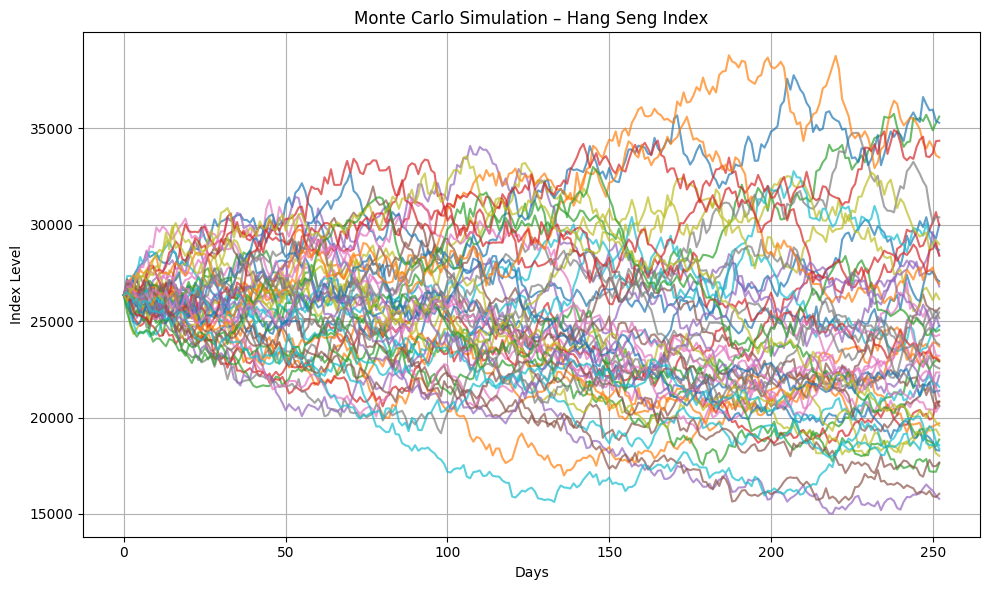

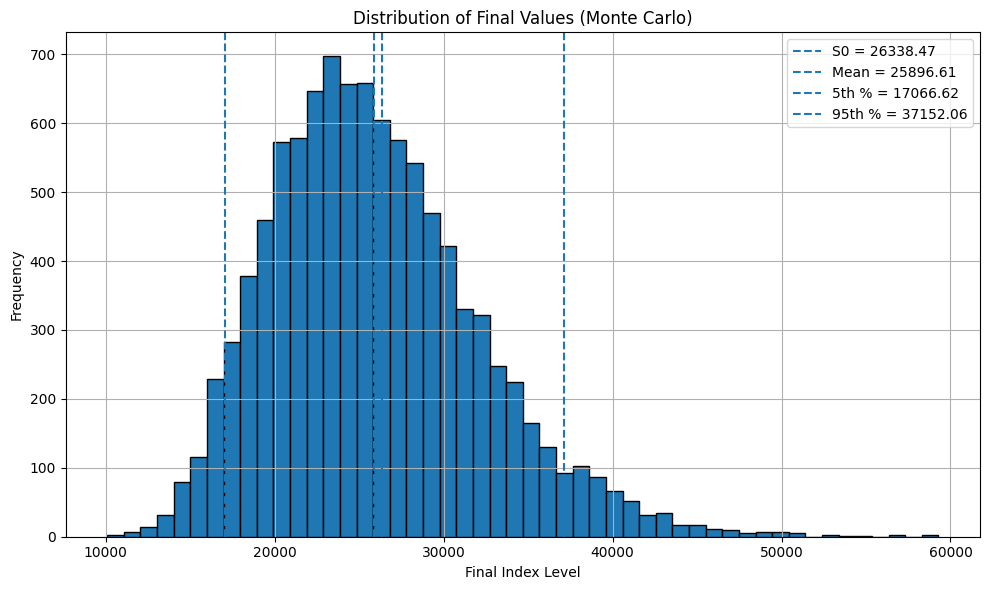

In [19]:

plt.figure(figsize=(10, 6))
time_axis = np.arange(n_steps + 1)

for i in range(50):  # 50 paths
    plt.plot(time_axis, price_paths[:, i], alpha=0.7)

plt.title("Monte Carlo Simulation – Hang Seng Index")
plt.xlabel("Days")
plt.ylabel("Index Level")
plt.grid(True)
plt.tight_layout()

#Histogram of final prices
plt.figure(figsize=(10, 6))
plt.hist(final_prices, bins=50, edgecolor="black")

plt.axvline(s0, linestyle="--", label=f"S0 = {s0:.2f}")
plt.axvline(expected_value, linestyle="--", label=f"Mean = {expected_value:.2f}")
plt.axvline(per5, linestyle="--", label=f"5th % = {per5:.2f}")
plt.axvline(per95, linestyle="--", label=f"95th % = {per95:.2f}")

plt.title("Distribution of Final Values (Monte Carlo)")
plt.xlabel("Final Index Level")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


